# Customer 360 — Churn Cutoff & Label-Window Selection

Chooses the churn label's **cutoff** and forward **window** from the data. Label is
*absolute inactivity*: an eligible customer (≥1 txn before cutoff) churns if they make
**zero** transactions in `[cutoff, cutoff + window)`.

Steps: locate the anomalous period the window must avoid → check cutoff feasibility →
sweep churn rate across cutoff × window → pick with a reproducible rule.

## Setup

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated", category=DeprecationWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Local thinking tool, not part of the deployed pipeline -- reads the raw CSVs directly.
DATA_DIR = next(
    (p for p in [Path("../data"), Path("../../data"), Path("data")] if p.exists()),
    Path("../data"),
)

# June-2025 bulk-reactivation spike boundary (established below). The label window
# must end before this date so the spike can't leak into the label.
SPIKE_START = pd.Timestamp("2025-06-01")

## Load Raw Data

Pipe-delimited CSVs; date columns parsed before analysis.

In [2]:
customers = pd.read_csv(DATA_DIR / "customer_raw.csv", sep="|")
enrollments = pd.read_csv(DATA_DIR / "product_enrollments.csv", sep="|")
transactions = pd.read_csv(DATA_DIR / "transaction_history.csv", sep="|")
crm = pd.read_csv(DATA_DIR / "crm_interactions.csv", sep="|")

customers["signup_date"] = pd.to_datetime(customers["signup_date"], format="mixed")
customers["date_of_birth"] = pd.to_datetime(customers["date_of_birth"], format="mixed")
enrollments["enrollment_date"] = pd.to_datetime(enrollments["enrollment_date"], format="mixed")
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"], format="mixed")
crm["interaction_date"] = pd.to_datetime(crm["interaction_date"], format="mixed")

for name, df in [("customers", customers), ("enrollments", enrollments), ("transactions", transactions), ("crm", crm)]:
    print(f"{name:15s} rows={len(df):>8,} cols={df.shape[1]:>3}")

customers       rows= 100,000 cols=  8
enrollments     rows= 140,089 cols=  5
transactions    rows= 886,971 cols=  6
crm             rows= 243,725 cols=  4


## Transaction Spike Metrics

Locates the abnormal period the label window must avoid: monthly txn volume, active
users, and txns/active-user (red line = `SPIKE_START`).

In [3]:
monthly_txn = (
    transactions
    .assign(month=transactions["transaction_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(
        transactions=("transaction_id", "count"),
        active_users=("customer_id", "nunique"),
        total_amount=("transaction_amount", "sum"),
        avg_amount=("transaction_amount", "mean"),
        median_amount=("transaction_amount", "median"),
        avg_closing_balance=("closing_balance", "mean"),
        median_closing_balance=("closing_balance", "median"),
    )
    .reset_index()
)
monthly_txn["txn_per_active_user"] = monthly_txn["transactions"] / monthly_txn["active_users"]
monthly_txn["transaction_growth_pct"] = monthly_txn["transactions"].pct_change()
monthly_txn["active_user_growth_pct"] = monthly_txn["active_users"].pct_change()

display(monthly_txn)

,month,transactions,active_users,total_amount,avg_amount,median_amount,avg_closing_balance,median_closing_balance,txn_per_active_user,transaction_growth_pct,active_user_growth_pct
0,2023-01-01,45,44,-2.117695e+06,-47059.887333,-41316.860,-47201.999333,-41316.860,1.022727,NaN,NaN
1,2023-02-01,121,120,-5.997103e+06,-49562.832397,-53083.680,-51689.912893,-53083.680,1.008333,1.688889,1.727273
2,2023-03-01,255,253,-1.258656e+07,-49359.040549,-51574.770,-50942.769059,-52514.130,1.007905,1.107438,1.108333
3,2023-04-01,335,332,-1.632745e+07,-48738.664925,-50416.970,-52104.137403,-53703.820,1.009036,0.313725,0.312253
4,2023-05-01,507,499,-2.324462e+07,-45847.370789,-49213.660,-49276.248619,-49959.350,1.016032,0.513433,0.503012
5,2023-06-01,607,597,-2.464968e+07,-40609.031631,-42486.710,-44951.272949,-46129.440,1.016750,0.197239,0.196393
6,2023-07-01,782,763,-3.446134e+07,-44068.210946,-45489.780,-49233.357737,-48778.890,1.024902,0.288303,0.278057
7,2023-08-01,927,909,-3.715849e+07,-40084.675210,-43653.070,-46825.757346,-47465.200,1.019802,0.185422,0.191350
8,2023-09-01,1120,1086,-4.385670e+07,-39157.764616,-40214.760,-45887.549214,-46226.605,1.031308,0.208198,0.194719
9,2023-10-01,1427,1387,-5.401649e+07,-37853.180259,-39294.320,-45843.222214,-43507.810,1.028839,0.274107,0.277164


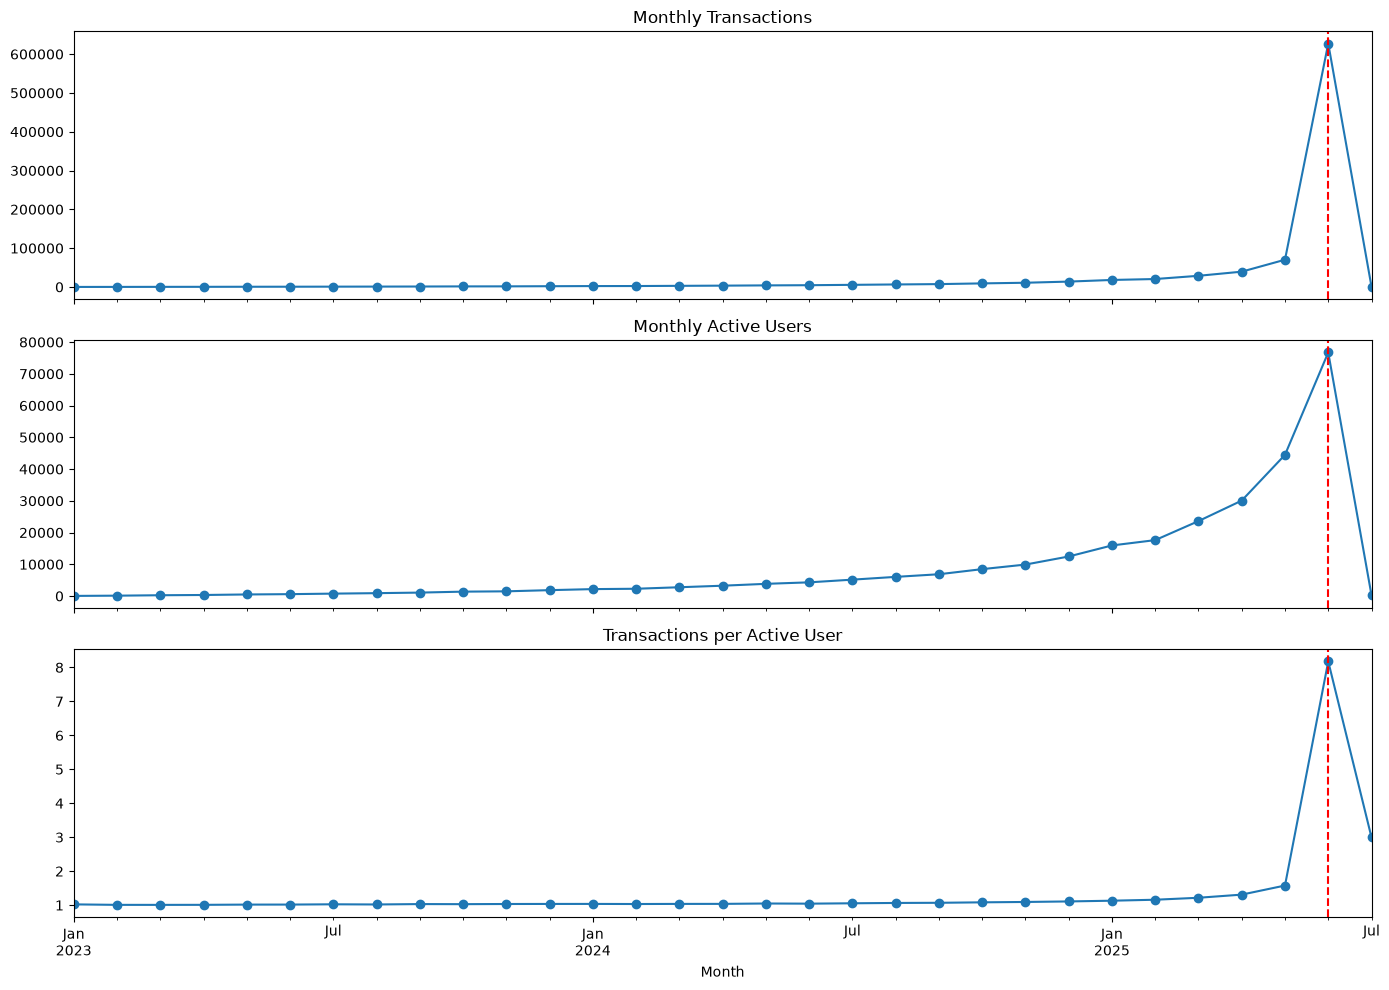

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
monthly_txn.plot(x="month", y="transactions", marker="o", ax=axes[0], legend=False)
monthly_txn.plot(x="month", y="active_users", marker="o", ax=axes[1], legend=False)
monthly_txn.plot(x="month", y="txn_per_active_user", marker="o", ax=axes[2], legend=False)
for ax in axes:
    ax.axvline(SPIKE_START, color="red", linestyle="--")
axes[0].set_title("Monthly Transactions")
axes[1].set_title("Monthly Active Users")
axes[2].set_title("Transactions per Active User")
axes[2].set_xlabel("Month")
plt.tight_layout()

**Result.** 2023-01 → 2025-05 grows smoothly, txns/active-user pinned at 1.0–1.6.
June 2025: transactions ≈627K (9× May's 70K, 22× March's 29K) vs. active users only
1.7× (44K → 77K) — a bulk **reactivation**, not organic growth. **Rule: the label
window must end strictly before 2025-06-01.**

## Cutoff Candidate Metrics

Feasibility per candidate cutoff (monthly grid, first 3 months in): eligible
population and days remaining for a full window.

In [5]:
candidate_cutoffs = pd.date_range(
    transactions["transaction_date"].min().to_period("M").to_timestamp() + pd.offsets.MonthBegin(3),
    transactions["transaction_date"].max().to_period("M").to_timestamp(),
    freq="MS",
)

cutoff_metric_rows = []
for cutoff_value in candidate_cutoffs:
    cutoff = pd.Timestamp(cutoff_value)
    prior_txn = transactions[transactions["transaction_date"] < cutoff]
    future_30 = transactions[(transactions["transaction_date"] >= cutoff) & (transactions["transaction_date"] < cutoff + pd.Timedelta(days=30))]
    future_60 = transactions[(transactions["transaction_date"] >= cutoff) & (transactions["transaction_date"] < cutoff + pd.Timedelta(days=60))]
    future_90 = transactions[(transactions["transaction_date"] >= cutoff) & (transactions["transaction_date"] < cutoff + pd.Timedelta(days=90))]
    signed_up = customers[customers["signup_date"] < cutoff]
    prior_customers = prior_txn["customer_id"].nunique()
    prior_txn_counts = prior_txn.groupby("customer_id")["transaction_id"].count()
    cutoff_metric_rows.append({
        "cutoff": cutoff,
        "signed_up_customers": signed_up["customer_id"].nunique(),
        "eligible_customers": prior_customers,
        "no_prior_txn_customers": signed_up["customer_id"].nunique() - prior_customers,
        "prior_txn_rows": len(prior_txn),
        "prior_txn_per_customer": len(prior_txn) / prior_customers if prior_customers else np.nan,
        "median_prior_txn_per_customer": prior_txn_counts.median() if prior_customers else np.nan,
        "future_30d_txn_customers": future_30["customer_id"].nunique(),
        "future_60d_txn_customers": future_60["customer_id"].nunique(),
        "future_90d_txn_customers": future_90["customer_id"].nunique(),
        "days_until_txn_end": (transactions["transaction_date"].max() - cutoff).days,
        "full_30d_window": cutoff + pd.Timedelta(days=30) <= transactions["transaction_date"].max(),
        "full_60d_window": cutoff + pd.Timedelta(days=60) <= transactions["transaction_date"].max(),
        "full_90d_window": cutoff + pd.Timedelta(days=90) <= transactions["transaction_date"].max(),
    })

cutoff_metrics = pd.DataFrame(cutoff_metric_rows)
cutoff_metrics["eligible_pct_of_signed_up"] = cutoff_metrics["eligible_customers"] / cutoff_metrics["signed_up_customers"]
cutoff_metrics["no_prior_txn_pct_of_signed_up"] = cutoff_metrics["no_prior_txn_customers"] / cutoff_metrics["signed_up_customers"]

display(cutoff_metrics)

,cutoff,signed_up_customers,eligible_customers,no_prior_txn_customers,prior_txn_rows,prior_txn_per_customer,median_prior_txn_per_customer,future_30d_txn_customers,future_60d_txn_customers,future_90d_txn_customers,days_until_txn_end,full_30d_window,full_60d_window,full_90d_window,eligible_pct_of_signed_up,no_prior_txn_pct_of_signed_up
0,2023-04-01,11859,412,11447,421,1.021845,1.0,332,804,1356,822,True,True,True,0.034742,0.965258
1,2023-05-01,15747,727,15020,756,1.039890,1.0,486,1052,1731,792,True,True,True,0.046168,0.953832
2,2023-06-01,19893,1197,18696,1263,1.055138,1.0,597,1291,2112,761,True,True,True,0.060172,0.939828
3,2023-07-01,23792,1746,22046,1870,1.071019,1.0,720,1571,2583,731,True,True,True,0.073386,0.926614
4,2023-08-01,27812,2439,25373,2652,1.087331,1.0,875,1923,3157,700,True,True,True,0.087696,0.912304
5,2023-09-01,31865,3229,28636,3579,1.108393,1.0,1086,2371,3735,669,True,True,True,0.101334,0.898666
6,2023-10-01,35831,4163,31668,4699,1.128753,1.0,1349,2764,4358,639,True,True,True,0.116184,0.883816
7,2023-11-01,39852,5317,34535,6126,1.152153,1.0,1485,3190,5081,608,True,True,True,0.133419,0.866581
8,2023-12-01,43779,6522,37257,7661,1.174640,1.0,1788,3762,5847,578,True,True,True,0.148976,0.851024
9,2024-01-01,47936,7962,39974,9582,1.203466,1.0,2115,4332,6685,547,True,True,True,0.166096,0.833904


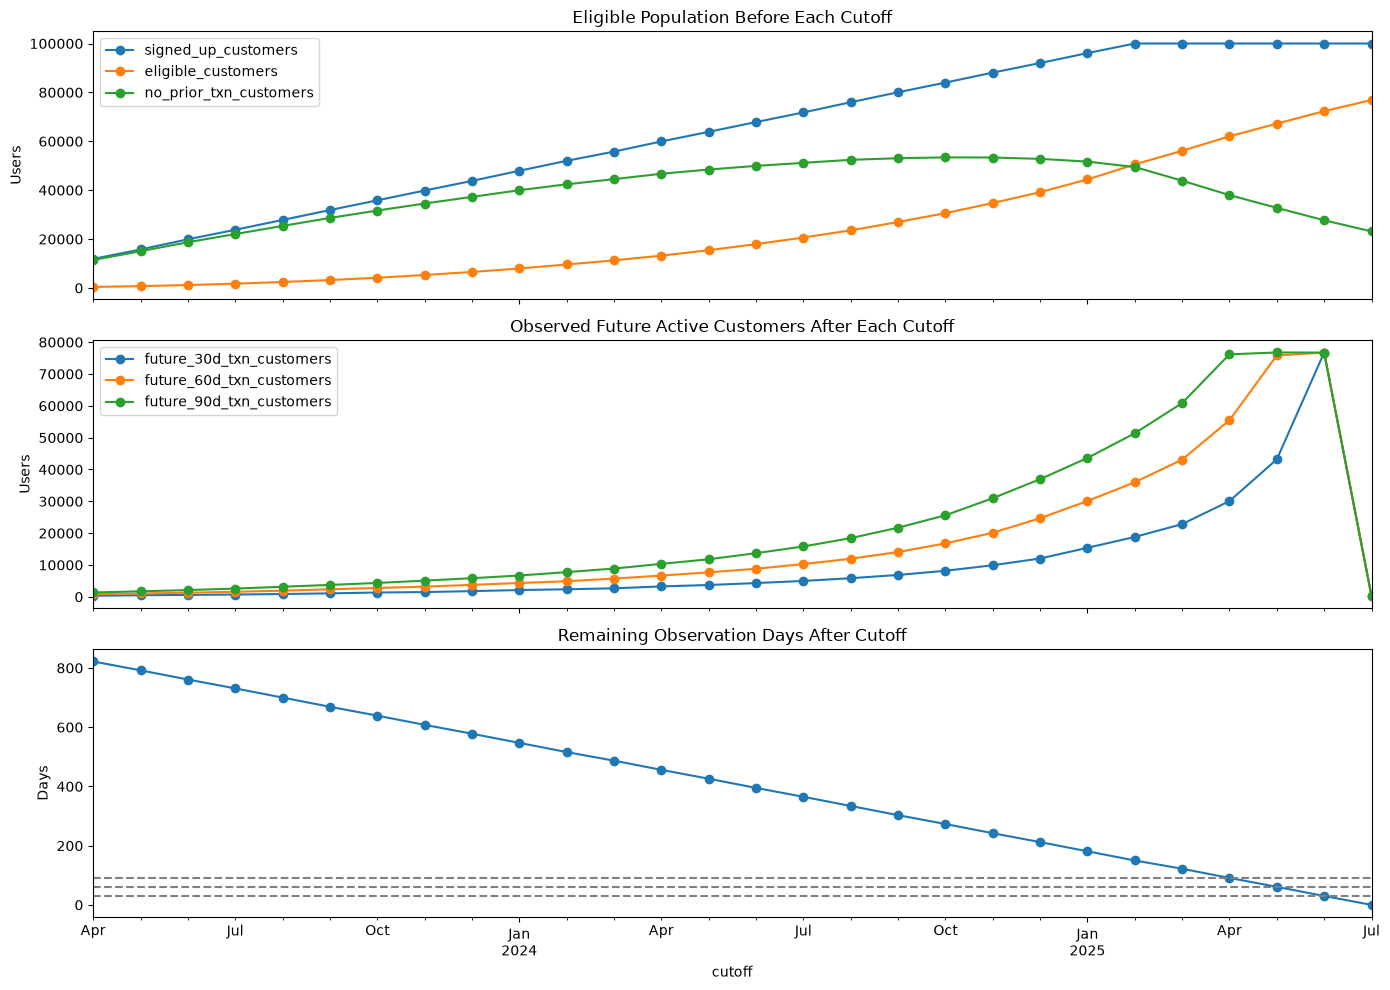

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
cutoff_metrics.plot(x="cutoff", y=["signed_up_customers", "eligible_customers", "no_prior_txn_customers"], marker="o", ax=axes[0])
cutoff_metrics.plot(x="cutoff", y=["future_30d_txn_customers", "future_60d_txn_customers", "future_90d_txn_customers"], marker="o", ax=axes[1])
cutoff_metrics.plot(x="cutoff", y=["days_until_txn_end"], marker="o", ax=axes[2], legend=False)
axes[0].set_title("Eligible Population Before Each Cutoff")
axes[1].set_title("Observed Future Active Customers After Each Cutoff")
axes[2].set_title("Remaining Observation Days After Cutoff")
axes[0].set_ylabel("Users")
axes[1].set_ylabel("Users")
axes[2].set_ylabel("Days")
axes[2].axhline(30, linestyle="--", color="gray")
axes[2].axhline(60, linestyle="--", color="gray")
axes[2].axhline(90, linestyle="--", color="gray")
plt.tight_layout()

**Result.** Eligible population is never scarce (≈44K → 62K, Jan → Apr). The
binding constraints are days remaining after cutoff and distance from the spike —
data ends 2025-07-01, so a 90-day window needs cutoff on/before ~2025-04.

## Label Window Sweep

Churn rate per cutoff × window ∈ {30, 60, 90}. Dashed lines mark the usable
`[0.05, 0.40]` band.

In [7]:
transactions_sorted = transactions[["customer_id", "transaction_date"]].copy()

def label_summary_for_cutoff(cutoff, label_window_days):
    cutoff = pd.Timestamp(cutoff)
    label_end = cutoff + pd.Timedelta(days=label_window_days)
    prior = transactions_sorted[transactions_sorted["transaction_date"] < cutoff]
    future = transactions_sorted[
        (transactions_sorted["transaction_date"] >= cutoff)
        & (transactions_sorted["transaction_date"] < label_end)
    ]
    eligible = prior["customer_id"].drop_duplicates()
    labeled = pd.DataFrame({"customer_id": eligible})
    future_customers = set(future["customer_id"])
    labeled["churn"] = (~labeled["customer_id"].isin(future_customers)).astype(int)
    return {
        "cutoff": cutoff,
        "label_window_days": label_window_days,
        "label_end": label_end,
        "eligible_customers": len(labeled),
        "churned": int(labeled["churn"].sum()),
        "churn_rate": labeled["churn"].mean() if len(labeled) else np.nan,
        "label_window_fits": label_end <= transactions["transaction_date"].max(),
    }

label_sweep = pd.DataFrame([
    label_summary_for_cutoff(pd.Timestamp(cutoff_value), window)
    for window in [30, 60, 90]
    for cutoff_value in candidate_cutoffs
])

display(label_sweep)

,cutoff,label_window_days,label_end,eligible_customers,churned,churn_rate,label_window_fits
0,2023-04-01,30,2023-05-01,412,395,0.958738,True
1,2023-05-01,30,2023-05-31,727,699,0.961486,True
2,2023-06-01,30,2023-07-01,1197,1149,0.959900,True
3,2023-07-01,30,2023-07-31,1746,1682,0.963345,True
4,2023-08-01,30,2023-08-31,2439,2322,0.952030,True
...,...,...,...,...,...,...,...
79,2025-03-01,90,2025-05-30,56114,11135,0.198435,True
80,2025-04-01,90,2025-06-30,62017,542,0.008740,True
81,2025-05-01,90,2025-07-30,67225,121,0.001800,False
82,2025-06-01,90,2025-08-30,72304,154,0.002130,False


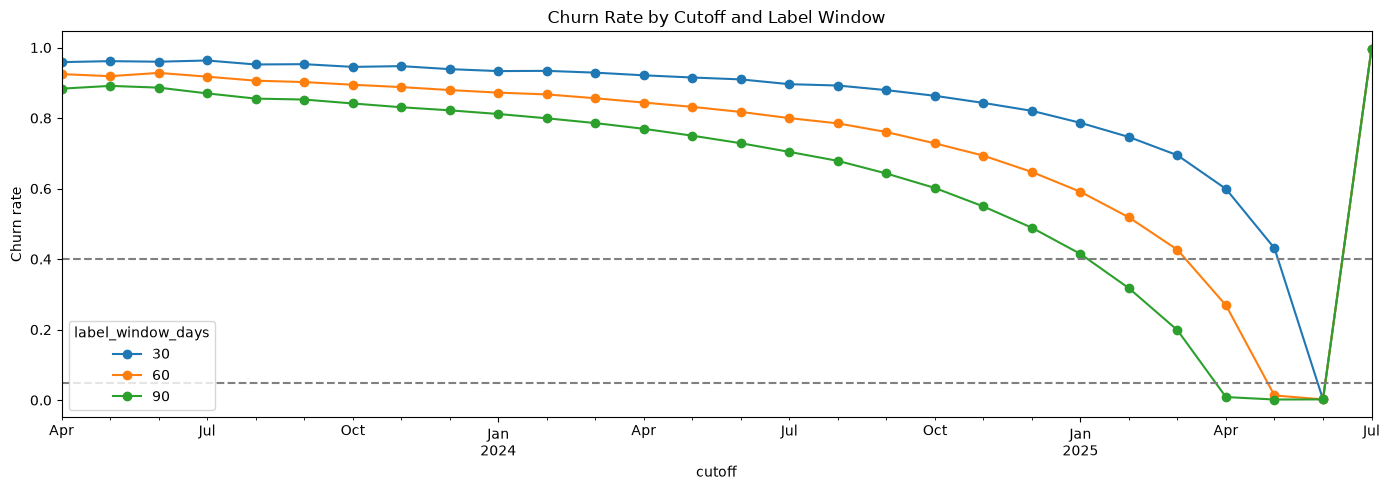

In [8]:
pivot = label_sweep.pivot(index="cutoff", columns="label_window_days", values="churn_rate")
ax = pivot.plot(figsize=(14, 5), marker="o")
ax.set_title("Churn Rate by Cutoff and Label Window")
ax.set_ylabel("Churn rate")
ax.axhline(0.05, linestyle="--", color="gray")
ax.axhline(0.40, linestyle="--", color="gray")
plt.tight_layout()

**Result.** Longer windows lower churn; churn collapses as cutoff nears June
(window starts catching the spike). 90d: Jan **0.415** → Feb **0.317** → Mar **0.198**
→ Apr **0.009** (degenerate — window overlaps the spike). 30d sits at 0.60–0.79,
above the band. **2025-03-01 × 90d = 0.198** is the moderate, non-degenerate rate.

## Label Stability & Distance from the Spike

Adds local churn-rate instability (swing vs. neighbouring months) and days from
`SPIKE_START`, per cutoff × window — feeds the decision table.

In [9]:
label_stability = label_sweep.sort_values(["label_window_days", "cutoff"]).copy()
label_stability["previous_churn_rate"] = label_stability.groupby("label_window_days")["churn_rate"].shift(1)
label_stability["next_churn_rate"] = label_stability.groupby("label_window_days")["churn_rate"].shift(-1)
label_stability["churn_rate_change_from_previous"] = (
    label_stability["churn_rate"] - label_stability["previous_churn_rate"]
).abs()
label_stability["churn_rate_change_to_next"] = (
    label_stability["next_churn_rate"] - label_stability["churn_rate"]
).abs()
label_stability["local_churn_rate_instability"] = label_stability[[
    "churn_rate_change_from_previous",
    "churn_rate_change_to_next",
]].max(axis=1)
label_stability["days_from_june_spike"] = (label_stability["cutoff"] - SPIKE_START).dt.days.abs()

display(label_stability[[
    "cutoff",
    "label_window_days",
    "eligible_customers",
    "churn_rate",
    "local_churn_rate_instability",
    "days_from_june_spike",
    "label_window_fits",
]])

,cutoff,label_window_days,eligible_customers,churn_rate,local_churn_rate_instability,days_from_june_spike,label_window_fits
0,2023-04-01,30,412,0.958738,0.002748,792,True
1,2023-05-01,30,727,0.961486,0.002748,762,True
2,2023-06-01,30,1197,0.959900,0.003445,731,True
3,2023-07-01,30,1746,0.963345,0.011315,701,True
4,2023-08-01,30,2439,0.952030,0.011315,670,True
...,...,...,...,...,...,...,...
79,2025-03-01,90,56114,0.198435,0.189696,92,True
80,2025-04-01,90,62017,0.008740,0.189696,61,True
81,2025-05-01,90,67225,0.001800,0.006940,31,False
82,2025-06-01,90,72304,0.002130,0.994189,0,False


## Combined Cutoff Decision Table

Pass/fail per candidate: churn rate ∈ `[0.05, 0.40]`, eligible ≥ 1,000, full window.
Sorted by pass flag, then longest window, then most recent cutoff.

In [10]:
cutoff_decision_metrics = label_stability.copy()

cutoff_decision_metrics["passes_basic_label_rules"] = (
    cutoff_decision_metrics["churn_rate"].between(0.05, 0.40)
    & (cutoff_decision_metrics["eligible_customers"] >= 1000)
    & cutoff_decision_metrics["label_window_fits"]
)

cutoff_decision_metrics = cutoff_decision_metrics.sort_values(
    ["passes_basic_label_rules", "label_window_days", "cutoff"],
    ascending=[False, False, False],
)

display(cutoff_decision_metrics[[
    "cutoff",
    "label_window_days",
    "eligible_customers",
    "churn_rate",
    "label_window_fits",
    "local_churn_rate_instability",
    "days_from_june_spike",
    "passes_basic_label_rules",
]])

,cutoff,label_window_days,eligible_customers,churn_rate,label_window_fits,local_churn_rate_instability,days_from_june_spike,passes_basic_label_rules
79,2025-03-01,90,56114,0.198435,True,0.189696,92,True
78,2025-02-01,90,50533,0.317436,True,0.119001,120,True
52,2025-04-01,60,62017,0.268942,True,0.255644,61,True
83,2025-07-01,90,76880,0.996319,False,0.994189,30,False
82,2025-06-01,90,72304,0.002130,False,0.994189,0,False
...,...,...,...,...,...,...,...,...
4,2023-08-01,30,2439,0.952030,True,0.011315,670,False
3,2023-07-01,30,1746,0.963345,True,0.011315,701,False
2,2023-06-01,30,1197,0.959900,True,0.003445,731,False
1,2023-05-01,30,727,0.961486,True,0.002748,762,False


## Valid Cutoff Candidates

Candidates that pass, ordered by longest window then most recent cutoff.

In [11]:
valid_cutoffs = cutoff_decision_metrics[
    cutoff_decision_metrics["passes_basic_label_rules"]
].copy()

valid_cutoffs = valid_cutoffs.sort_values(
    ["label_window_days", "cutoff"],
    ascending=[False, False],
)

display(valid_cutoffs[[
    "cutoff",
    "label_window_days",
    "eligible_customers",
    "churn_rate",
    "label_window_fits",
    "local_churn_rate_instability",
    "days_from_june_spike",
]])

,cutoff,label_window_days,eligible_customers,churn_rate,label_window_fits,local_churn_rate_instability,days_from_june_spike
79,2025-03-01,90,56114,0.198435,True,0.189696,92
78,2025-02-01,90,50533,0.317436,True,0.119001,120
52,2025-04-01,60,62017,0.268942,True,0.255644,61


In [12]:
# Selection rule: among candidates that pass, prefer spike-safe -> longest window ->
# most recent cutoff (no composite score).
selection = valid_cutoffs.copy()
selection["window_end"] = selection["cutoff"] + pd.to_timedelta(selection["label_window_days"], unit="D")
selection = selection[selection["window_end"] <= SPIKE_START]
selection = selection.sort_values(["label_window_days", "cutoff"], ascending=[False, False])

chosen = selection.iloc[0]
print(f"Selected cutoff : {chosen['cutoff'].date()}")
print(f"Forward window  : {int(chosen['label_window_days'])}d  (ends {chosen['window_end'].date()}, before {SPIKE_START.date()})")
print(f"Eligible pop.   : {int(chosen['eligible_customers']):,}")
print(f"Base rate       : {chosen['churn_rate']:.3f}")

Selected cutoff : 2025-03-01
Forward window  : 90d  (ends 2025-05-30, before 2025-06-01)
Eligible pop.   : 56,114
Base rate       : 0.198


## Decision

Three candidates pass: **2025-02-01 (90d)**, **2025-03-01 (90d)**, **2025-04-01 (60d)**.
Rule picks **2025-03-01 × 90d**.

- **Spike-safe.** All three end before the June spike.
- **Longest window wins** over April's 60d.
- **Most recent** of the two 90d candidates — freshest history, largest eligible
  population (56,114 vs. 50,533).
- **Base rate 0.198** vs. February's 0.317 — February sits further up the spike ramp,
  labelling more short activity gaps as churn.